In [63]:

import tensorflow as tf
import numpy as np 
import json 
from numba import njit

fire = 1
output_length = 10

@njit
def magnitude(x: np.ndarray) -> int | float:
    return np.sqrt(np.sum(x**2))

@njit
def max_normalize(data: np.ndarray):
    return data / np.max(data)

@njit
def gaussian_normalize(data: np.ndarray):
    return (data - np.mean(data, axis=0)) / (np.std(data, axis=0) + 1e-8)


def hot_encode(x: np.ndarray, output_length: (int | float)) -> np.ndarray:
    """
    Converts an array of integer indices into one-hot encoded vectors.

    Parameters:
        x (np.array): Array of integer indices.
        output_length (int): Length of the one-hot encoded vectors.

    Returns:
        np.array: A 2D array where each row is a one-hot encoded vector
        corresponding to the input indices.
    """
    tmp = []
    for index in x:
        x_vec = np.zeros(output_length)
        x_vec[int(index)] = fire
        tmp.append(x_vec.reshape((output_length)))
    return np.array(tmp)


def prepare_data(
    dataset: "tf.keras.datasets" = "mnist", normalize_scheme: callable = max_normalize
) -> tuple[np.ndarray]:
    """
    Prepares and preprocesses a dataset for training and testing.

    Parameters:
        dataset (str): Name of the dataset to load from tf.keras.datasets (default: 'mnist').
        normalize_scheme (function): Function to normalize the dataset
        (default: max_normalize).

    Returns:
        tuple: Preprocessed training and testing data:
            - x_train (np.array): Flattened and normalized training input data.
            - y_train (np.array): One-hot encoded training labels.
            - x_test (np.array): Flattened and normalized testing input data.
            - y_test (np.array): One-hot encoded testing labels.
    """
    # Dynamically get the dataset
    try:
        dataset_module = getattr(tf.keras.datasets, dataset)
    except AttributeError:
        raise ValueError(f"Dataset '{dataset}' not found in tf.keras.datasets")
    (x_train, y_train), (x_test, y_test) = dataset_module.load_data()
    x_train, y_train = np.array(x_train, dtype=float), np.array(y_train, dtype=float)

    # Take n number of 28*28 matrices and convert them to 784 vectors
    (r, m, n), (rt, mt, nt) = x_train.shape, x_test.shape
    dim_x, dim_xt = (r, m * n), (rt, mt * nt)
    x_train, x_test = x_train.reshape(dim_x), x_test.reshape(dim_xt)

    y_train, y_test = (
        hot_encode(y_train, output_length),
        hot_encode(y_test, output_length),
    )

    # normalize datasets
    # x_train = (x_train - np.mean(x_train, axis=0)) / (np.std(x_train, axis=0) + 1e-8)
    # x_test = (x_test - np.mean(x_test, axis=0)) / (np.std(x_test, axis=0) + 1e-8)
    x_train, x_test = map(normalize_scheme, [x_train, x_test])

    return x_train, y_train, x_test, y_test


def read_weights(file:str = "./mnist_a0.0_lr-2_shots20_width16.json", weight_label: str = "last_params",**kwargs) ->list[np.ndarray[:,:]]:
    """
    Read weight matrices from a JSON file and return them as a list of numpy arrays.

    This function opens the specified JSON file, loads its content, and then extracts
    a list of weights using the provided weight_label key. Each weight in the list is
    converted into a numpy array.

    Parameters:
        file : str
            The path to the JSON file containing the weight data.
        weight_label : str, optional
            The key in the JSON file corresponding to the weights to be loaded.
            Defaults to "last_params".

    Returns:
        list[np.ndarray]
            A list of numpy arrays representing the weight matrices extracted from the JSON file.
    """

    with open(file, **kwargs) as f:
        data = json.load(f)

    weights = data[weight_label]
    weights = [np.array(w) for w in weights]
    return weights 


In [147]:
from qiskit import QuantumCircuit , QuantumRegister,ClassicalRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler, Session 
import numpy as np
from matplotlib import pyplot as plt
import natural_quantization

#TODO: enforce one classical data type
#TODO: make sure we select qubits with furthest connectivity 

def htanh(x:np.ndarray[:],a:(int | float))-> np.ndarray[:]:
    """
    Compute a hard tanh activation on the input x.

    This function applies a piecewise transformation to x:
      - When |x| ≤ a, it returns x/a.
      - When |x| > a, it returns 1 if x is positive, and -1 otherwise.
      - For a = 0, the function directly returns the sign of x.
    
    Parameters:
      x : array-like or scalar
          The input value(s) to be transformed.
      a : float
          The threshold parameter (with |a| ≤ 1) that defines the linear region.
    
    Returns:
      Transformed value(s) following the hard tanh definition applied element-wise.
    
    Raises:
      AssertionError: If the absolute value of a is greater than 1.
    """
    
    assert abs(a) <= 1

    if a == 0:
        return np.where(x>0,1,-1)
    else: 
        return np.where(abs(x)<=a, x/a, np.where(x>0,1,-1))


class QuantumNeuralNetwork():

    """
    A hybrid classical–quantum feedforward neural network built on Qiskit Runtime.

    This class implements a multi-layer network where the first and last layers
    are classical linear transforms and intermediate hidden layers are executed
    as parameterized single-qubit quantum circuits. Each hidden layer’s pre‑activation
    vector is converted into rotation angles, the qubits are measured, and the
    resulting bitstring is used as input to the next layer. The final layer applies
    a classical softmax to produce output probabilities.

    Attributes
    ----------
    layer_sizes : list of int
        Sizes of each layer, including input, hidden, and output layers.
    layer_n : int
        Total number of layers.
    hidden_layer_n : int
        Number of hidden (quantum) layers.
    b : list of np.ndarray
        Bias vectors for each layer (starting from the first hidden layer).
    W : list of np.ndarray
        Weight matrices for each layer transition.
    activation_f : callable
        A function mapping (pre‑activation, quantumness) → activation, e.g. `htanh`.
    service : QiskitRuntimeService or None
        Initialized IBM runtime service after calling `establish_communication_with_ibm`.
    backend : Qiskit backend or None
        Selected device or simulator for quantum circuit execution.
    comms : pass manager or None
        Communication pass manager for circuit compilation.
    """

    def __init__(self,
                 layer_sizes:list,
                 activation_f:callable=htanh) -> "QuantumNeuralNetwork":
        
        self.layer_sizes = layer_sizes
        self.layer_n = len(layer_sizes)
        self.hidden_layer_n = len(layer_sizes) - 2
        self.b = [np.random.randn(layer_sizes[i]) for i in range(1, self.hidden_layer_n + 2)]
        self.W = [np.random.randn(layer_sizes[i], 
                                  layer_sizes[i - 1]) * np.sqrt(1 / layer_sizes[i - 1]) for i in range(1, self.hidden_layer_n + 2)]

        self.activation_f = activation_f
        self.service = None
        self.backend = None
        self.comms = None


    def establish_communication_with_ibm(self,
                                         simulation_mode=True,
                                         operational=True,
                                         optimization_level=3) -> None:
        
        """
    Initialize Qiskit runtime service, select a backend, and configure the communications pass manager.

    This method logs into the IBM Qiskit runtime service, chooses the least-busy backend
    supporting sessions and measurements (either a simulator or a real device), and
    generates a preset pass manager with the specified optimization level for compiling circuits.

    Parameters
    ----------
    simulation_mode : bool, optional
        Whether to prefer a simulator backend (True) or a real device (False). Default is True.
    operational : bool, optional
        Whether to restrict selection to operational (online) backends (True) or include offline ones (False). Default is True.
    optimization_level : int, optional
        The optimization level (0–3) for the communications pass manager. Higher values apply more aggressive optimizations. Default is 3.

    Raises
    ------
    ConnectionError
        If initializing QiskitRuntimeService or selecting the backend fails.
    RuntimeError
        If generating the communications pass manager fails.
        """

        try:
            # Initialize the runtime service (assumes you're logged in)
            self.service = QiskitRuntimeService()
        except Exception as e:
            raise ConnectionError("Failed to initialize QiskitRuntimeService.") from e

        try:
            # Choose a backend with session and measurement support
            self.backend = self.service.least_busy(simulator=simulation_mode,
                                                   operational=operational)
        except Exception as e:
            raise ConnectionError("Failed to select a backend.") from e

        try:
            # Generate the communication pass manager
            self.comms = generate_preset_pass_manager(backend=self.backend,
                                                      optimization_level=optimization_level)
        except Exception as e:
            raise RuntimeError("Failed to generate the communications pass manager.") from e



    def feedforward(self: "QuantumNeuralNetwork",input:np.ndarray[:],quantumness=.5) -> np.ndarray[:]:

        """
    Perform a hybrid classical–quantum feedforward pass through the network.

    This method processes the input vector through a classical linear layer,
    then for each hidden layer builds and runs a parameterized quantum circuit
    whose rotation angles are determined by the difference between the pre‑activation
    zs and the activations computed by `self.activation_f`. The measurement outcomes
    of each quantum circuit become the inputs to the next layer. Finally, it
    applies a softmax transformation on the last linear readout layer to produce
    output probabilities.

    Parameters
    ----------
    self : QuantumNeuralNetwork
        The network instance, which must have attributes `weights`, `activation_f`,
        `comms`, and `backend` configured.
    input : np.ndarray, shape (n_input,)
        The input feature vector for the network.
    quantumness : float, optional
        A value between 0 and 1 controlling the interpolation between purely
        classical (0) and fully quantum (1) hidden‑layer activations. Default is 0.5.

    Returns
    -------
    np.ndarray, shape (n_output,)
        The output probability vector from the final softmax layer.
        """

        # take classical steps 
        zs = self.weights[0]@input
        for i in range(1,len(self.weights)-1):
            θ = np.pi/2*( zs - self.activation_f(self.weights[i]@zs,quantumness))
            n_qbits = self.weights[i].shape[0]
            qr = QuantumRegister(n_qbits,name="qr")
            cr = ClassicalRegister(n_qbits,name="cr")
            qc = QuantumCircuit(qr, cr)
            for i,Θ in enumerate(θ):
                qc.ry(theta=Θ, qubit=i)
                qc.measure(qubit=i,cbit=i)
            isa_circuit = self.comms.run(qc)
            sampler = Sampler(mode=self.backend)
            job = sampler.run([isa_circuit], shots=1)
            result = job.result()
            counts = result[0].data.cr.get_counts()
            zs = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)

        ## apply softmax to final layer 
        output =  np.exp(self.weights[-1]@zs)/sum(np.exp(self.weights[-1]@ zs))
        return output
         

    def predict(self,
                Xs,
                quantumness=.5, 
                n_samples=10)->list[np.ndarray[:]]:


        """
    Generate multiple stochastic predictions for each input using the hybrid quantum–classical network.

    Parameters
    ----------
    Xs : Iterable[np.ndarray]
        A collection of input vectors to predict on. Each element should be a 1D numpy array
        matching the network's input dimension.
    quantumness : float, optional
        Interpolation parameter between purely classical (0.0) and fully quantum (1.0) hidden-layer
        activations. Defaults to 0.5.
    n_samples : int, optional
        Number of stochastic forward passes to perform per input. Defaults to 10.

    Returns
    -------
    list[np.ndarray]
        A flat list of output probability vectors from all runs, with length equal to
        `len(Xs) * n_samples`. Each element is the softmax output of one forward pass.
        """

        output = []
        for x in Xs:
            for i in range(n_samples): 
                tmp = self.feedforward(x,quantumness)
                output.append(tmp)
                print("shot #{i}",np.argmax(tmp))
        return output 

In [148]:
x_train,y_train,x_test,y_test = prepare_data()
weights = read_weights(file="/Users/dlakhdar/physics/repos/natural-quantization/data/quantum_nn_rotation_angles/mnist_a0.5_lr-2_shots20_width16.json")
qnn = QuantumNeuralNetwork(layer_sizes=[784,16,16,16,10],
                     activation_f=htanh)

qnn.weights = [np.array(w) for w in weights]
#choose an instance 
x_test_sample = [x_test[0]]
y_test_sample = [y_test[0]]

In [149]:
qnn.establish_communication_with_ibm(simulation_mode=False,operational=True)
results = qnn.predict(x_test_sample)

2
8
0
6
2
7
7
1
5
4


[array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])]

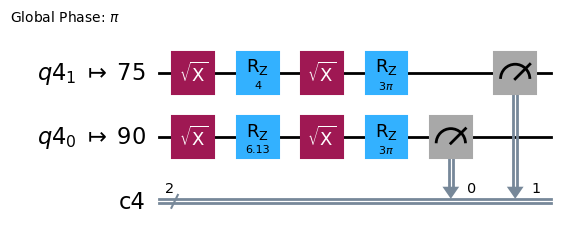

In [89]:
σ = np.tanh
input= np.array([0,1,1,0])
layer_sizes = [4,2,2,3]

layer_sizes = layer_sizes
layer_n = len(layer_sizes)
hidden_layer_n = len(layer_sizes) - 2
b = [np.random.randn(layer_sizes[i]) for i in range(1, hidden_layer_n + 2)]
W = [np.random.randn(layer_sizes[i], 
                                  layer_sizes[i - 1]) * np.sqrt(1 / layer_sizes[i - 1]) for i in range(1, hidden_layer_n + 2)]

service = QiskitRuntimeService()  # Assumes you're logged in
# Choose a backend with session + measurement support
backend = service.least_busy(simulator=False, operational=True)

θ0 = np.pi/2*( 1- σ(W[0]@input))

qr = QuantumRegister(W[0].shape[0])
cr = ClassicalRegister(W[0].shape[0])
qc = QuantumCircuit(qr, cr)

for i,Θ in enumerate(θ0):
     qc.ry(theta=Θ, qubit=i)
     qc.measure(qubit=i,cbit=i)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl")

In [90]:
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1)
result = job.result()

In [24]:
counts = result[0].data.c0.get_counts()
arr = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)
arr
θ1 = np.pi/2*( 1- W[1] @ arr)

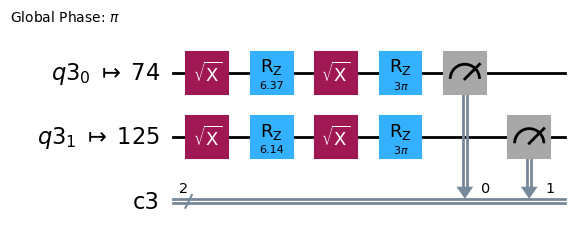

In [27]:
qr = QuantumRegister(W[1].shape[0])
cr = ClassicalRegister(W[1].shape[0])
qc = QuantumCircuit(qr, cr)

for i,Θ in enumerate(θ1):
     qc.ry(theta=Θ, qubit=i)
     qc.measure(qubit=i,cbit=i)

isa_circuit = pm.run(qc)

isa_circuit.draw("mpl")

In [28]:
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1)
result = job.result()

In [36]:
counts = result[0].data.c3.get_counts()
arr = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)
np.tanh(W[2] @ arr)

array([-0.200135  , -0.84789994, -0.56906341])

np.float64(-0.20013500237806772)

In [41]:
σ = np.tanh
input= np.array([0,1,1,0])
layer_sizes = [4,2,2,3]

layer_sizes = layer_sizes
layer_n = len(layer_sizes)
hidden_layer_n = len(layer_sizes) - 2
b = [np.random.randn(layer_sizes[i]) for i in range(1, hidden_layer_n + 2)]
W = [np.random.randn(layer_sizes[i], 
                                  layer_sizes[i - 1]) * np.sqrt(1 / layer_sizes[i - 1]) for i in range(1, hidden_layer_n + 2)]


service = QiskitRuntimeService()  # Assumes you're logged in
# Choose a backend with session + measurement support
backend = service.least_busy(simulator=False, operational=True)
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

zs = input

#TODO: make sure we select qubits with furthest connectivity 

for i in range(len(W)-1):

     θ = np.pi/2*( 1- np.tanh(W[i]@zs))
     n_qbits = W[i].shape[0]
     qr = QuantumRegister(n_qbits,name="qr")
     cr = ClassicalRegister(n_qbits,name="cr")
     qc = QuantumCircuit(qr, cr)

     for i,Θ in enumerate(θ):
          qc.ry(theta=Θ, qubit=i)
          qc.measure(qubit=i,cbit=i)

     isa_circuit = pm.run(qc)
     sampler = Sampler(mode=backend)
     job = sampler.run([isa_circuit], shots=1)
     result = job.result()
     counts = result[0].data.cr.get_counts()
     zs = np.fromiter((int(b) for b in next(iter(counts))), dtype=np.float16)


output =  np.exp(W[-1]@zs)/sum(np.exp(W[-1]@ zs))

In [43]:
output =  np.exp(W[-1]@zs)/sum(np.exp(W[-1]@ zs))

In [44]:
output

array([0.50166485, 0.17629738, 0.32203777])

In [128]:
print(htanh(x_test_sample[0],.5))

None


In [151]:
500/60*5

41.66666666666667

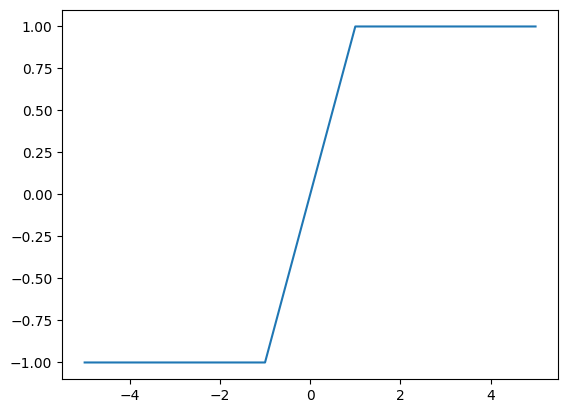

In [171]:
plt.plot(arr, htanh(arr,1))

In [177]:
import natural_quantization.preprocess

ModuleNotFoundError: No module named 'natural_quantization.preprocess'

In [178]:
for i in range(0,3):
    print(i)

0
1
2
